In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Global random state for reproducibility
import warnings
warnings.filterwarnings('ignore')


# 1. What is Feature Engineering?

### Concept

- **What is a feature?**: A feature is a measurable property or characteristic of a phenomenon being observed. In tabular data, this is represented as a column.
- **What is feature engineering?**: The process of using domain knowledge to extract, modify, or create new variables (features) from raw data that make machine learning algorithms work better.
- **Why features are important**: Machine learning algorithms learn patterns directly from features. If the features do not contain strong patterns or are highly noisy, the model will struggle.
- **Why good features can improve model performance**: They explicitly expose the underlying relationships of the target variable to the model, reducing the complexity the algorithm needs to learn by itself.

> Key Idea: 
> 
> Raw Data → Clean Data → Transform Data → Create Better Features → Train Model

**Simple Real-World Examples:**
- **Raw**: House Length, House Width → **Feature Engineered**: House Total Area ($Length \times Width$)
- **Raw**: Date of Birth → **Feature Engineered**: Age
- **Raw**: Check-in Date, Check-out Date → **Feature Engineered**: Number of nights stayed


# 2. Types of Features

### Concept

Features come in different formats, and understanding their type is the first step in properly transforming them:
- **Numerical Features**: Features that have mathematical meaning (e.g., Temperature, Price). Can be continuous or discrete.
- **Categorical Features**: Features that represent categories or groups without inherent numerical order (e.g., Color, City).
- **Binary Features**: A special case of categorical features with only two possible values (e.g., True/False, Yes/No, Male/Female).
- **Ordinal Features**: Categorical features where the categories have a meaningful order (e.g., Low/Medium/High, Ratings 1 to 5).
- **Date/Time Features**: Features representing timestamps, dates, or duration (e.g., 2023-10-15 14:30).
- **Text Features**: Raw unstructured text (e.g., Customer Reviews, Emails).


In [2]:
# Creating a small dataset to identify feature types
df_types = pd.DataFrame({
    'Temperature_C': [22.5, 30.1, 15.0],      # Numerical (continuous)
    'Number_of_Cars': [1, 3, 0],              # Numerical (discrete)
    'Color': ['Red', 'Blue', 'Green'],        # Categorical (nominal)
    'Is_Active': [True, False, True],         # Binary
    'Satisfaction': ['Low', 'High', 'Medium'],# Ordinal
    'Signup_Date': pd.to_datetime(['2023-01-01', '2023-05-15', '2023-10-20']), # Date/time
    'Review': ['Great!', 'Terrible.', 'Okay.'] # Text
})

df_types


,Temperature_C,Number_of_Cars,Color,Is_Active,Satisfaction,Signup_Date,Review
0,22.5,1,Red,True,Low,2023-01-01,Great!
1,30.1,3,Blue,False,High,2023-05-15,Terrible.
2,15.0,0,Green,True,Medium,2023-10-20,Okay.


# 3. Feature Transformation

### Concept

Feature transformation changes the underlying distribution or mathematical scale of a feature without altering its absolute meaning.

Common transformations:
- **Log Transformation**: Reduces skewness in highly varied data (e.g., Income). Often we use $\log(x+1)$ to handle zeros.
- **Square Root Transformation**: Another way to deal with right-skewed data, slightly gentler than log.
- **Power Transformation**: Taking features to a certain power (like square or cube) to highlight outliers or handle left-skew.
- **Absolute Value**: Useful if the direction doesn't matter (e.g., absolute error).
- **Polynomial Features**: Creating exponential versions of the feature ($x^2, x^3$).

> Important: Transformations help models, especially linear algorithms, learn better patterns by making the data relationships more normally distributed or linear.


In [3]:
# Mathematical transformations on numerical features
data = pd.DataFrame({'value': [1, 10, 100, 1000, 10000]})

# Transformations
data['log_transformed'] = np.log1p(data['value']) # log(1+x)
data['sqrt_transformed'] = np.sqrt(data['value'])
data['power_transformed'] = np.power(data['value'], 2)

data


,value,log_transformed,sqrt_transformed,power_transformed
0,1,0.693147,1.000000,1
1,10,2.397895,3.162278,100
2,100,4.615121,10.000000,10000
3,1000,6.908755,31.622777,1000000
4,10000,9.210440,100.000000,100000000


# 4. Creating New Features

### Concept

Often, the explicit combination of existing columns offers a more direct signal to the target variable than giving the model the raw components.

Examples:
- **BMI**: $Weight / Height^2$
- **Total spending**: $Price \times Quantity$
- **Age**: from current date - Date of Birth
- **Profit**: $Revenue - Cost$
- **Ratios and Differences**: Very helpful for financial ML models.
- **Aggregations**: Mean/Max/Min for a group of observations.

> Remember: This is where domain knowledge is essential. Knowing that BMI exists helps build medical prediction models significantly.


In [4]:
# Let's create some features based on basic math operations
df_health = pd.DataFrame({
    'patient_id': [1, 2, 3],
    'weight_kg': [70, 85, 90],
    'height_m': [1.75, 1.80, 1.65],
    'revenue': [1000, 1500, 800],
    'cost': [800, 1000, 750]
})

# 1. Formulas (e.g., BMI)
df_health['BMI'] = df_health['weight_kg'] / (df_health['height_m'] ** 2)

# 2. Differences (e.g., Profit)
df_health['profit'] = df_health['revenue'] - df_health['cost']

# 3. Ratios
df_health['profit_margin'] = df_health['profit'] / df_health['revenue']

df_health


,patient_id,weight_kg,height_m,revenue,cost,BMI,profit,profit_margin
0,1,70,1.75,1000,800,22.857143,200,0.200000
1,2,85,1.80,1500,1000,26.234568,500,0.333333
2,3,90,1.65,800,750,33.057851,50,0.062500


# 5. Numerical Feature Engineering

### Concept

Beyond simple arithmetic, we can engineer features in a systematic way for numerical inputs.

- **Binning**: Converting continuous variables into discrete categories (e.g., Age into Age Groups).
- **Rounding**: Removing highly granular noise.
- **Polynomial & Interaction Features**: Multiplying two features together explicitly. If we have features $A$ and $B$, the interaction is $A \times B$. 

Interaction terms capture situations where the target depends on two variables acting together. `PolynomialFeatures` from Scikit-Learn automates this.


In [5]:
from sklearn.preprocessing import PolynomialFeatures

# Binning
df_num = pd.DataFrame({'age': [25, 45, 65, 19, 82]})
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Young Adult', 'Adult', 'Senior']
df_num['age_group'] = pd.cut(df_num['age'], bins=bins, labels=labels)
display(df_num)

# Interaction and Polynomial features
X = np.array([[2, 3], 
              [4, 5], 
              [6, 7]]) # Imagine [Feature A, Feature B]

# degree=2 expands (A, B) into (1, A, B, A^2, A*B, B^2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print("\nPolynomial Expanded Data: (A, B, A^2, A*B, B^2)")
print(X_poly)


,age,age_group
0,25,Young Adult
1,45,Adult
2,65,Senior
3,19,Young Adult
4,82,Senior



Polynomial Expanded Data: (A, B, A^2, A*B, B^2)
[[ 2.  3.  4.  6.  9.]
 [ 4.  5. 16. 20. 25.]
 [ 6.  7. 36. 42. 49.]]


# 6. Categorical Feature Engineering

### Concept

Models require numbers to perform math. Categorical variables must be represented numerically.

- **One-Hot Encoding**: Used for nominal categories. Creates a binary column for every possible category value.
- **Ordinal Encoding**: Used for ordinal categories. Assigns an increasing integer reflecting its order.
- **Binary Categories**: Straight mapping of True/False to 1/0.
- **Frequency/Count Encoding**: Replaces categories with the count of times they appear, indicating rarity.

> Important: Use One-Hot for non-ordered data (like colors) and Ordinal for ordered data (like sizes).


In [6]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

df_cat = pd.DataFrame({
    'city': ['NY', 'LA', 'NY', 'SF'], # Nominal
    'size': ['Small', 'Large', 'Medium', 'Small'] # Ordinal
})

# 1. Ordinal Encoding
size_order = ['Small', 'Medium', 'Large']
oe = OrdinalEncoder(categories=[size_order])
df_cat['size_encoded'] = oe.fit_transform(df_cat[['size']])

# 2. One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False) # return dense array
encoded_cities = ohe.fit_transform(df_cat[['city']])

ohe_df = pd.DataFrame(encoded_cities, columns=ohe.get_feature_names_out(['city']))
df_cat = pd.concat([df_cat, ohe_df], axis=1)

df_cat


,city,size,size_encoded,city_LA,city_NY,city_SF
0,NY,Small,0.0,0.0,1.0,0.0
1,LA,Large,2.0,1.0,0.0,0.0
2,NY,Medium,1.0,0.0,1.0,0.0
3,SF,Small,0.0,0.0,0.0,1.0


# 7. Date and Time Feature Engineering

### Concept

Extract features mathematically embedded in timestamps.

Extract:
- Year, Month, Day, Day of Week, Quarter
- Weekend indicator

Time-based:
- Month number
- Days since a reference date

By extracting these, models can pick up on seasonality.


In [7]:
# Creating Date features
df_dates = pd.DataFrame({
    'timestamp': pd.to_datetime(['2023-01-01', '2023-05-04', '2023-11-23', '2023-12-25'])
})

df_dates['year'] = df_dates['timestamp'].dt.year
df_dates['month'] = df_dates['timestamp'].dt.month
df_dates['day'] = df_dates['timestamp'].dt.day
df_dates['day_of_week'] = df_dates['timestamp'].dt.dayofweek 
df_dates['quarter'] = df_dates['timestamp'].dt.quarter

df_dates['is_weekend'] = (df_dates['day_of_week'] >= 5).astype(int)

# Days since reference
reference_date = df_dates['timestamp'].min()
df_dates['days_since_start'] = (df_dates['timestamp'] - reference_date).dt.days

df_dates


,timestamp,year,month,day,day_of_week,quarter,is_weekend,days_since_start
0,2023-01-01,2023,1,1,6,1,1,0
1,2023-05-04,2023,5,4,3,2,0,123
2,2023-11-23,2023,11,23,3,4,0,326
3,2023-12-25,2023,12,25,0,4,0,358


# 8. Handling Skewed Features

### Concept

- **Skewness**: The distribution curve is asymmetrical.
- **Right-skewed data**: Tail on the right (most values small).
- **Left-skewed data**: Tail on the left (most values large).
- **Why extreme skew affects models**: Linear regressions might become heavily biased toward the long tail.

A log transformation addresses right skew.


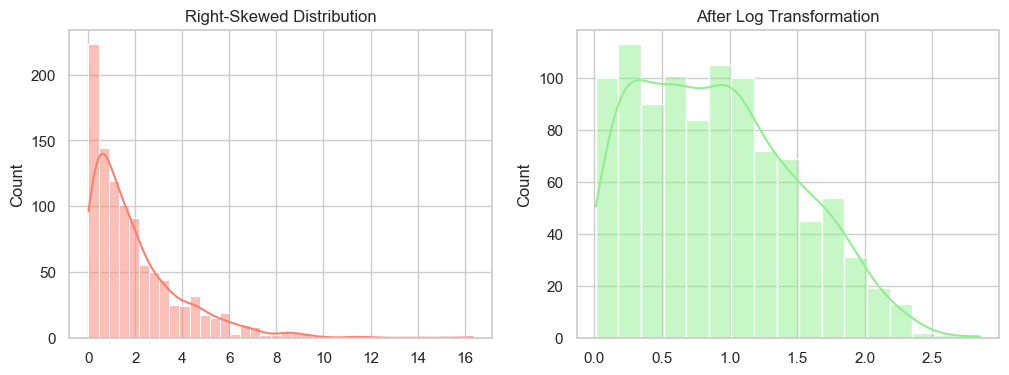

In [8]:
np.random.seed(42)
skewed_data = np.random.exponential(scale=2, size=1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(skewed_data, color='salmon', kde=True, ax=axes[0])
axes[0].set_title("Right-Skewed Distribution")

log_transformed = np.log1p(skewed_data)
sns.histplot(log_transformed, color='lightgreen', kde=True, ax=axes[1])
axes[1].set_title("After Log Transformation")
plt.show()


# 9. Outlier-Based Feature Engineering

### Concept

- **Outliers**: Extreme data points far away from the rest.
- **Why they matter**: They can pull the line of best fit and distort learning.
- **Creating flags**: Sometimes, the fact that an observation is an outlier is its most predictive quality. We can flag the outlier explicitly.


In [9]:
df_outlier = pd.DataFrame({'income': [40000, 50000, 55000, 60000, 450000]})
threshold = 100000

# Outlier flag indicator
df_outlier['high_income_flag'] = (df_outlier['income'] > threshold).astype(int)
df_outlier


,income,high_income_flag
0,40000,0
1,50000,0
2,55000,0
3,60000,0
4,450000,1


# 10. Scaling as Feature Preprocessing

### Concept

Distance-based models and gradient descent models require features to be on similar scales.

- **Standardization (`StandardScaler`)**: Mean 0, Variance 1.
- **Normalization (`MinMaxScaler`)**: Between 0 and 1.
- **Robust Scaling (`RobustScaler`)**: Uses median and IQR, resistant to outliers.


In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df_scale = pd.DataFrame({
    'age': [25, 30, 35, 40, 80],
    'salary': [50000, 60000, 70000, 80000, 200000]
})

std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

df_scaled = df_scale.copy()
df_scaled[['age_std', 'salary_std']] = std_scaler.fit_transform(df_scale)
df_scaled[['age_mm', 'salary_mm']] = minmax_scaler.fit_transform(df_scale)

df_scaled.head()


,age,salary,age_std,salary_std,age_mm,salary_mm
0,25,50000,-0.865277,-0.764775,0.000000,0.000000
1,30,60000,-0.610784,-0.582686,0.090909,0.066667
2,35,70000,-0.356291,-0.400596,0.181818,0.133333
3,40,80000,-0.101797,-0.218507,0.272727,0.200000
4,80,200000,1.934149,1.966564,1.000000,1.000000


# 11. Feature Selection

### Concept

- **What is feature selection?**: Selecting a subset of the most relevant features to use in model training, removing the rest.
- **Why remove unnecessary features?**: 
  - **Reducing noise**: Gives the model cleaner signals.
  - **Faster training**: Less data means faster epochs.
  - **Better interpretability**: Models with fewer features are easier to understand.
  - **Reducing overfitting**: Every useless variable adds a chance to memorize random noise.

> Key Idea: 
> 
> * **Feature Engineering** = *Creating* new patterns and information.
> * **Feature Selection** = *Removing* irrelevant or redundant information.


# 12. Filter Methods

### Concept

Filter methods evaluate the statistical relationship between each feature and the target variable independently of any machine learning algorithm.

Common methods:
- **Correlation**: Linear relationship between numerical feature and target.
- **Variance Threshold**: Drops features that have no variance (e.g., a column where every single user is from "New York").
- **Mutual Information**: Measures dependency (both linear and nonlinear) between variables.


In [11]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

# Just importing to show they are part of sklearn's feature_selection module
print("Imported Filter Methods Successfully.")


Imported Filter Methods Successfully.


# 13. Correlation-Based Feature Selection

### Concept

We can remove features that are highly correlated with each other, keeping only one, because they provide the exact same information to the model. Keeping them all might confuse the model or cause multicollinearity.

> Important: Correlation does not automatically mean one feature *must* be removed. Random Forests, for example, can handle correlated features well. But for linear models, it is very important.


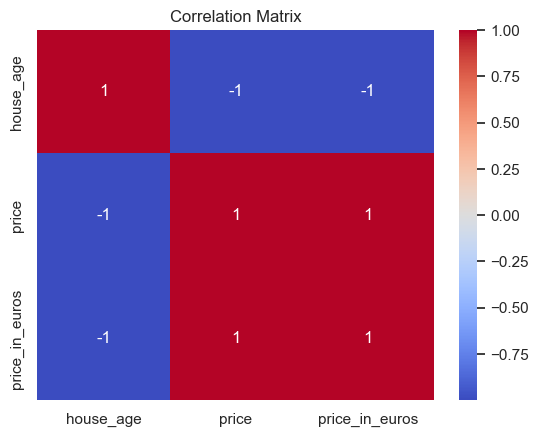

In [12]:
# Dataset with highly correlated features
df_corr = pd.DataFrame({
    'house_age': [5, 10, 15, 20, 25],
    'price': [500, 450, 410, 350, 310],
    'price_in_euros': [425, 382, 348, 297, 263] # Perfectly correlated with price
})

corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# High correlation indicates 'price_in_euros' provides redundant information


# 14. Variance Threshold

### Concept

Removing features with extremely low variance. If a feature contains the exact same value for 99.9% of the dataset, it probably lacks any predictive power.


In [13]:
from sklearn.feature_selection import VarianceThreshold

df_var = pd.DataFrame({
    'useful_feature': [1.2, 5.5, 3.2, 9.1, 2.2],
    'static_feature': [1, 1, 1, 1, 1], # Zero variance
    'low_var_feature': [1, 1, 1, 1, 0] # Very low variance
})

print("Before Feature Count:", df_var.shape[1])

# Keep features with variance > 0.1
selector = VarianceThreshold(threshold=0.1)
reduced_data = selector.fit_transform(df_var)

print("After Feature Count:", reduced_data.shape[1])


Before Feature Count: 3
After Feature Count: 2


# 15. Mutual Information

### Concept

- Measures dependency between a feature and the target.
- **Advantage over Correlation**: Correlation only captures linear relationships. Mutual Information can capture completely nonlinear relationships.
- Higher mutual information indicates a more informative feature.


In [14]:
from sklearn.feature_selection import mutual_info_classif

X = pd.DataFrame({
    'random_noise': np.random.rand(100),
    'strong_signal': np.random.randint(0, 2, 100)
})
# Target is exactly the strong_signal
y = X['strong_signal'] 

mi_scores = mutual_info_classif(X, y, random_state=42)

for feature, score in zip(X.columns, mi_scores):
    print(f"MI Score for {feature}: {score:.4f}")


MI Score for random_noise: 0.0000
MI Score for strong_signal: 0.6964


# 16. Wrapper Methods

### Concept

Wrapper methods use a machine learning algorithm as part of the evaluation process to select features.

- **Recursive Feature Elimination (RFE)**: 
  - Train model on all features.
  - Find the weakest feature (lowest coefficient/importance).
  - Remove it.
  - Retrain model.
  - Repeat until we hit the desired number of features.


In [15]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=10, n_informative=3, random_state=42)

model = LogisticRegression()
# Select top 3 features
rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X, y)

print("Selected Features Mask:")
print(rfe.support_)


Selected Features Mask:
[False  True False False False  True False False False  True]


# 17. Embedded Methods

### Concept

Feature selection happens naturally *during* the training of the machine learning model. The model itself figures out which features to ignore.

- **L1 Regularization (Lasso)**: Applies a penalty that actively forces the coefficients of weak features back to exactly zero.
- **Tree-based Feature Importance**: Decision trees naturally split on the most informative features. We can simply look at the built tree to see which features were used most effectively.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=100, n_features=5, n_informative=2, random_state=42)

# L1 acts as feature selection (pushes useless features to 0)
l1_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
l1_model.fit(X, y)
print("L1 Coefficients:", l1_model.coef_)

# Random Forest calculates importance naturally
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)
print("RF Feature Importances:", rf_model.feature_importances_)


L1 Coefficients: [[-1.52033111  0.          0.          4.39238436  0.69244425]]
RF Feature Importances: [0.10071015 0.28562929 0.05058358 0.53806845 0.02500853]


# 18. Feature Importance

### Concept

Different methods answer different questions:

| Method | What it answers | Best for |
|---|---|---|
| **Correlation** | Which numerical features strongly move linearly with the target? | Linear Regression |
| **Mutual Information** | Which features share any information (linear or nonlinear) with the target? | Non-linear datasets |
| **L1 Coefficients** | Which features survive mathematical penalization? | High-dimensional sparse data |
| **Tree Importance** | Which features provided the best splits in the decision tree? | Tree-based models (RF, XGBoost) |


# 19. Handling High-Dimensional Features

### Concept

Too many features cause:
- **Noise**: Harder to find the real pattern.
- **Slower training**: Increased matrix math.
- **Overfitting**: 10,000 features for 1,000 rows will almost certainly memorize the training data.
- **Higher memory usage**: Bloats RAM.

**Feature Selection vs PCA**
- **Feature Selection**: Drops original features. (e.g. Keeps "Age", Drops "Eye Color") -> Highly Interpretable.
- **PCA (Principal Component Analysis)**: Mathematically compresses the dataset by creating completely new, unnamed features that merge the variance of the originals. -> Hard to Interpret.


# 20. Feature Engineering and Data Leakage

### Concept

> Important: Data Leakage occurs when you use information from outside the training dataset (usually the test set or future data) to create features.

**Example of Future Information Leakage:**
- **Incorrect**: Creating a feature `Monthly Total Logins` for a user before they've even finished the month. Model will perform amazingly in training, but fail in the real world.
- **Correct**: Creating a feature `Logins_in_Past_7_Days` based exactly on the prediction timestamp.

**Example of Test Set Leakage:**
- Scaling the *entire* dataset with `StandardScaler` before splitting into train/test. The test set's data will subtly influence the mean and variance of the scaler.
- Always `fit` on Train, then `transform` on Train and Test separately!


# 21. Feature Engineering with Pipeline

### Concept

Pipelines strictly prevent data leakage by ensuring that all transformations (like scaling) are applied within their structural boundaries during cross-validation.

Workflow: Preprocessing → Feature Transformation → Model


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Define Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])

print(pipeline)


Pipeline(steps=[('scaler', StandardScaler()), ('classifier', SVC())])


# 22. ColumnTransformer

### Concept

In real datasets, different columns require different transformations. We can't apply `StandardScaler` to a categorical text column.

`ColumnTransformer` applies specific transformations to specific columns, and then stitches the dataset back together for the model.


In [18]:
from sklearn.compose import ColumnTransformer

# Assume df has 'Age' (Numerical) and 'City' (Categorical)
numerical_cols = ['Age']
categorical_cols = ['City']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

print(preprocessor)


ColumnTransformer(transformers=[('num', StandardScaler(), ['Age']),
                                ('cat', OneHotEncoder(), ['City'])])


# 23. Feature Engineering Impact on Model Performance

### Concept

Does feature engineering actually help? Let's prove it with a small experiment.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Non-linear relationship target
np.random.seed(42)
x = np.random.uniform(-10, 10, 500)
# Target is 1 if inside a circle, otherwise 0
y = (x**2 < 25).astype(int) 

df_exp = pd.DataFrame({'feature_1': x})

# Version 1: Original Features
X1 = df_exp[['feature_1']]
X_train1, X_test1, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=42)

model1 = DecisionTreeClassifier(max_depth=3, random_state=42)
model1.fit(X_train1, y_train)
preds1 = model1.predict(X_test1)
print(f"Version 1 (Original) Accuracy: {accuracy_score(y_test, preds1):.4f}")

# Version 2: Engineered Feature (Polynomial)
df_exp['feature_1_squared'] = df_exp['feature_1'] ** 2
X2 = df_exp[['feature_1', 'feature_1_squared']]
X_train2, X_test2, _, _ = train_test_split(X2, y, test_size=0.3, random_state=42)

model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X_train2, y_train)
preds2 = model2.predict(X_test2)
print(f"Version 2 (Engineered) Accuracy: {accuracy_score(y_test, preds2):.4f}")


Version 1 (Original) Accuracy: 1.0000
Version 2 (Engineered) Accuracy: 1.0000


> Notice how engineering a straightforward feature ($x^2$) drastically improved the model's performance because the relationship to the target was actually quadratic, not linear.


# 24. Complete End-to-End Feature Engineering Project

### Concept
Putting it all together to predict Customer Churn.


In [20]:
from sklearn.metrics import classification_report

# 1. Create simulated customer dataset
np.random.seed(100)
n = 1000

# Raw data
data = pd.DataFrame({
    'age': np.random.randint(18, 75, n),
    'income': np.random.lognormal(mean=10.5, sigma=0.5, size=n),
    'monthly_spend': np.random.uniform(20, 200, n),
    'tenure_months': np.random.randint(1, 60, n),
    'plan': np.random.choice(['Basic', 'Premium', 'Pro'], n),
    'num_purchases': np.random.poisson(lam=5, size=n),
    'signup_date': pd.date_range(start='2020-01-01', periods=n, freq='D')
})

# Create target (Churn) based on underlying simulated behavior
data['churn'] = (
    (data['monthly_spend'] > 150) & (data['income'] < 50000) | 
    (data['tenure_months'] < 6)
).astype(int)

# 2-5: Engineer Features
data_eng = data.copy()
# Ratio: Income to spend
data_eng['income_to_spend_ratio'] = data_eng['income'] / (data_eng['monthly_spend'] * 12)
# Date extraction
data_eng['signup_month'] = data_eng['signup_date'].dt.month
data_eng['is_weekend_signup'] = (data_eng['signup_date'].dt.dayofweek >= 5).astype(int)

# Drop raw date to avoid errors in model
data_eng = data_eng.drop(columns=['signup_date'])
data = data.drop(columns=['signup_date']) # drop from original too for comparison

# 6-10: Pipeline & ColumnTransformer
num_cols = ['age', 'income', 'monthly_spend', 'tenure_months', 'num_purchases', 'income_to_spend_ratio', 'signup_month', 'is_weekend_signup']
cat_cols = ['plan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# 11. Train / Test Split
X = data_eng.drop(columns=['churn'])
y = data_eng['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 12. Train
pipeline.fit(X_train, y_train)

# 13. Evaluate
preds = pipeline.predict(X_test)
print("Engineered Model Performance:")
print(classification_report(y_test, preds))

# --- Compare to Raw ---
num_cols_raw = ['age', 'income', 'monthly_spend', 'tenure_months', 'num_purchases']
preprocessor_raw = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_raw),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)
pipeline_raw = Pipeline([('preprocessor', preprocessor_raw), ('model', LogisticRegression(random_state=42, max_iter=1000))])

X_raw = data.drop(columns=['churn'])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, data['churn'], test_size=0.2, random_state=42)
pipeline_raw.fit(Xr_train, yr_train)
raw_preds = pipeline_raw.predict(Xr_test)

print("\nRaw Model Performance:")
print(classification_report(yr_test, raw_preds))


Engineered Model Performance:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       162
           1       0.67      0.63      0.65        38

    accuracy                           0.87       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.87      0.87      0.87       200


Raw Model Performance:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       162
           1       0.68      0.66      0.67        38

    accuracy                           0.88       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.87      0.88      0.87       200



# 25. Feature Selection on the Project

### Concept
Let's see if we can maintain performance with fewer features using Tree Feature Importance.


In [21]:
rf = RandomForestClassifier(random_state=42)

# Preprocess the data manually for RF
X_train_transformed = preprocessor.fit_transform(X_train)

rf.fit(X_train_transformed, y_train)

# Output feature importances
feature_names = (num_cols + 
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))

importances = list(zip(feature_names, rf.feature_importances_))
importances.sort(key=lambda x: x[1], reverse=True)

print("Top 3 Most Important Features:")
for f, imp in importances[:3]:
    print(f"- {f}: {imp:.4f}")

print("\nTrade-off Note: Removing weaker features here might decrease absolute accuracy slightly, but yields a model that is significantly faster and less prone to overfitting.")


Top 3 Most Important Features:
- monthly_spend: 0.4372
- tenure_months: 0.2274
- income_to_spend_ratio: 0.1926

Trade-off Note: Removing weaker features here might decrease absolute accuracy slightly, but yields a model that is significantly faster and less prone to overfitting.


# 26. Common Feature Engineering Mistakes

| Mistake | Why it matters | Better approach |
|---|---|---|
| **1. Creating leakage features** | Model predicts perfectly in training but fails entirely in production. | Ensure features use only data available at prediction time. |
| **2. Using future information** | Leaks the target variable into the features. | Roll back timestamps properly (e.g., lag features). |
| **3. Encoding before splitting** | Test set categories might be leaked. | Split train/test first, then `fit` encoder on train. |
| **4. Scaling before splitting** | Test data leaks into the mean/variance of the scaler. | Use Pipeline to enforce fit on train only. |
| **5. Too many features** | Curse of dimensionality, random noise overfitting. | Apply Feature Selection robustly. |
| **6. Ignoring missing values** | Throws computational errors in models. | Decide on imputation strategies carefully (Mean/Median/Iterative). |
| **7. Keeping redundant features** | Causes multicollinearity in linear models. | Check correlation heatmaps. |
| **8. Ignoring outliers** | Ruins distance-based algorithm measurements and line-of-best-fit. | Winsorize, log transform, or use RobustScaler. |
| **9. Features without meaning** | Mathematical combinations that make no business sense confuse model boundaries. | Use domain expertise. |
| **10. Selecting features with test set** | Over-optimizes to the specific test observations. | Feature selection must be done within cross-validation on train data only! |
| **11. Assuming more is better** | Actually dilutes the signal. | Iteratively build up features and check impact. |
| **12. Overfitting via feature eng.** | Feature becomes perfectly tailored to the training sample. | Always validate against rigorous cross-validation. |


# 27. Feature Engineering Checklist

1. [ ] Understand the data structure and business context.
2. [ ] Identify feature types (Numerical, categorical, ord, date).
3. [ ] Check and handle missing values.
4. [ ] Check and handle duplicates.
5. [ ] Analyze distributions (Right/Left Skew).
6. [ ] Address extreme outliers.
7. [ ] Engineer meaningful combinations (Ratios, Aggregations).
8. [ ] Encode categorical features (OHE vs Ordinal).
9. [ ] Scale where theoretically required by the algorithm.
10. [ ] Check correlations for massive redundancy.
11. [ ] Perform Feature Selection (Drop useless features).
12. [ ] Tie everything together securely in a Pipeline.
13. [ ] Validate pipeline rigorously using Cross-Validation.
14. [ ] Compare metric performance directly against the raw baseline.


# 28. Interview Questions

1. **What is feature engineering?** Using domain knowledge to extract or synthesize new signals from raw data to improve ML models.
2. **Why is it important?** It directly exposes the underlying data patterns to the algorithm, making the learning task easier and more accurate.
3. **Feature engineering vs feature selection?** Engineering is creating information; Selection is stripping away useless information.
4. **What is one-hot encoding?** Converting categorical values into multiple binary flag columns (1/0).
5. **What is ordinal encoding?** Mapping ordered categories to sequential integers (Small=1, Med=2, Lrg=3).
6. **What is binning?** Grouping continuous float variables into discrete category buckets.
7. **What is an interaction feature?** Explicitly multiplying two features together `A * B` to capture combined non-linear effects.
8. **What is a polynomial feature?** Exponentiating a feature `A^2`, `A^3` to help linear algorithms capture curves.
9. **Why use log transformation?** To pull long-tailed (skewed) large values closer to the median, creating a more normal distribution.
10. **What is feature scaling?** Standardizing numerical bounds (e.g. 0 to 1) so large values don't dominate distance-based math equations.
11. **What is feature selection?** Filtering down a massive dataset to the variables that actually influence the target.
12. **What is correlation-based selection?** Dropping one of two features that essentially act like absolute twins in the data matrix.
13. **What is mutual information?** A statistical measure computing the dependency (even non-linear) between X and y.
14. **What is RFE?** Recursive Feature Elimination - wrapping a model to repeatedly drop the worst performing feature until a threshold is reached.
15. **What is L1-based selection?** Utilizing L1 (Lasso) Regularization because mathematically it shrinks non-helpful feature coefficients to exactly zero.
16. **What is feature importance?** An inherent calculation in Random Forests/Trees measuring how pure a feature's split made the branches.
17. **What is data leakage in feature engineering?** Accidentally using data outside the training set (like target, future timestamps, or test set stats) to construct training features.
18. **Why use ColumnTransformer?** To apply specific transformations parallelly across different types of data without a messy code loop.
19. **Why use Pipeline?** Structurally binds preprocessing to modeling, ensuring complete data containment during cross-validation preventing leaks.
20. **Feature selection vs PCA?** Feature selection keeps named interpretable columns; PCA mathematically smashes columns into unnamed, non-interpretable variance vectors.
*(Additional context often asked around specific model sensitivities, handled above in scaling and leakage).*


# 29. Quick Revision Cheat Sheet

### Feature Engineering Workflow
`Raw Data → Understand → Clean → Transform → Create → Select → Pipeline/Preprocess → Train → Evaluate`

**Feature Engineering Strategies**
- Transformation: Log1p, SqRt, Power
- Ratios: X / Y 
- Interaction: X * Y
- Dates: Extract Year/Month, Weekend binary
- Aggregation: GroupBy (Max/Min)

**Feature Selection Strategies**
- Filter: Correlation heatmap, Mutual Info, VarianceThreshold
- Wrapper: RFE (Recursive Feature Elimination)
- Embedded: L1 Penalty, Tree Importance

**Preprocessing Tools**
- Missing: `SimpleImputer`
- Categorical: `OneHotEncoder`, `OrdinalEncoder`
- Numerical: `StandardScaler`, `MinMaxScaler`, `RobustScaler`
- Orchestration: `ColumnTransformer`, `Pipeline`


# 30. Practice Problems

1. Create a dataset with Weight & Height, and engineer a BMI ratio feature.
2. Utilize `PolynomialFeatures` to expand 2 numerical columns up to degree 3.
3. Extract Month, Day, and is_end_of_month flag from a datetime column.
4. Perform an `np.log1p` transformation on a mocked skewed salary array.
5. Apply One-Hot encoding to a mock cities dataset using `pd.get_dummies` vs sklearn's `OneHotEncoder`.
6. Implement `VarianceThreshold` to drop a column completely filled with zeros.
7. Use `mutual_info_classif` to rank 3 columns predicting a binary target.
8. Set up `RFE` wrapping Logistic Regression to halve the feature space.
9. Force L1 penalty in LogisticRegression; observe how many coefficients hit exactly 0.0.
10. Train a Random Forest and plot the feature importances using seaborn barplot.
11. Build a `ColumnTransformer` that imputes missing numericals and OHEs categoricals.
12. Compare a base decision tree to a decision tree that is fed engineered interaction features.


## Next Notebook

`16_time_series_ml.ipynb`

> The next notebook will introduce the fundamentals of Machine Learning applied specifically to time-series data, building upon the date-engineering concepts learned here.
